In [4]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('fraud.csv')

# Quick overview
print(df.shape)
print(df.info())
print(df.head())

# Strip whitespace and lowercase all column names to avoid key errors
df.columns = df.columns.str.strip().str.lower()

(6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        4155

## Now here we are:-
Checking for missing values

Understanding data types

Looking at class imbalance (fraud is usually rare)

Correlation heatmap to find relationships

step              0
type              0
amount            0
nameorig          0
oldbalanceorg     0
newbalanceorig    0
namedest          0
oldbalancedest    0
newbalancedest    0
isfraud           0
isflaggedfraud    0
dtype: int64


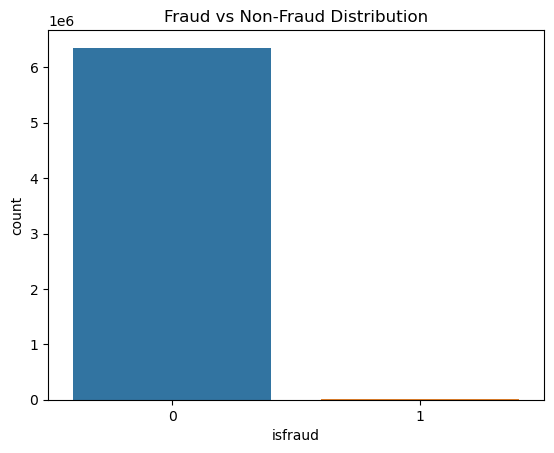

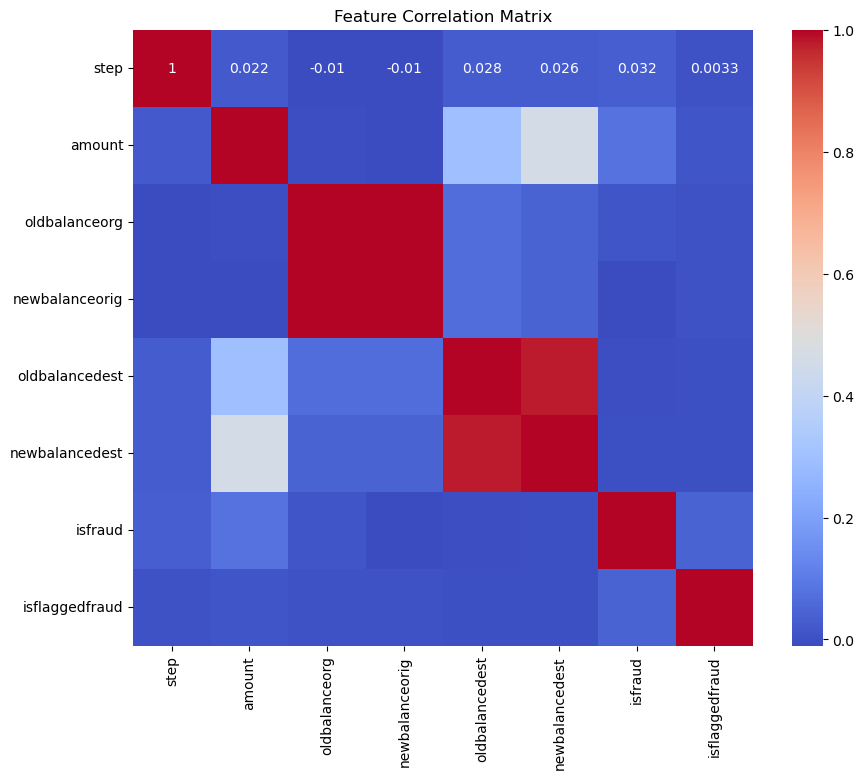

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Missing values
print(df.isnull().sum())

# Fraud distribution
sns.countplot(x='isfraud', data=df)
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()

# Select numeric columns only
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# 1. Drop unnecessary high-cardinality columns
df.drop(["nameorig", "namedest"], axis=1, inplace=True)

# 2. One-hot encode the 'type' column (5 categories total: manageable size)
df = pd.get_dummies(df, columns=["type"], drop_first=True)

# 3. Split features and label
X = df.drop('isfraud', axis=1)  # Features
y = df['isfraud']               # Target

# 4. Feature scaling (important for algorithms like Logistic Regression, SVM, etc.)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train-test split (stratify ensures fraud proportion stays same in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print("✅ Preprocessing complete.")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

✅ Preprocessing complete.
Train shape: (4453834, 11) Test shape: (1908786, 11)


In [8]:
print(list(df.columns)) #Just for reference to avoid further key errors

['step', 'amount', 'oldbalanceorg', 'newbalanceorig', 'oldbalancedest', 'newbalancedest', 'isfraud', 'isflaggedfraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = RandomForestClassifier(n_estimators=1, random_state=1, n_jobs=-1)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))


[[1905913     409]
 [    524    1940]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.83      0.79      0.81      2464

    accuracy                           1.00   1908786
   macro avg       0.91      0.89      0.90   1908786
weighted avg       1.00      1.00      1.00   1908786

ROC AUC Score: 0.8935615565321224


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [1,1],
    'max_depth': [1,1],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, scoring='roc_auc', cv=3)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)

In [ ]:
importances = model.feature_importances_
features = X.columns

feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(feat_imp_df.head(10))

# Plot
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features')
plt.show()